In [54]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("IBM-HR-Analytics-Employee-Attrition-and-Performance-Revised.csv")

missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

df_cleaned = df.dropna()
print(df_cleaned)


Missing values in each column:
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64
      Age Attrition     B

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   str  
 7   EducationField            1470 non-null   str  
 8   EnvironmentSatisfaction   1470 non-null   str  
 9   Gender                    1470 non-null   str  
 10  HourlyRate                1470 non-null   int64
 11  JobInvolvement            1470 non-null   str  
 12  JobLevel                  1470 non-null   str  
 13  JobRole                   1470 non-null   str  
 14  JobSatisfaction           1470 non-null   str  
 15

In [56]:
label_encoders = {}
for i in df.columns:
  if df[i].dtypes == 'object':
      le = LabelEncoder()
      df[i] = le.fit_transform(df[i])
      label_encoders[i] = le
  print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome      Education EducationField EnvironmentSatisfaction  \
0                 1        College  Life Sciences                  Medium   
1                 8  Below College  Life Sciences                    High   
2                 2        College          Other               Very High   
3                 3         Master  Life Sciences               Very High   
4                 2  Below College        Medical                     Low   

   Gender  ...  PerformanceRating RelationshipSatisfaction StockOptionLevel  \
0  Female  ..

### Attrition Distribution

C:\Users\moustafa\AppData\Local\Temp\ipykernel_20568\641834663.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attrition_counts.index, y=attrition_counts.values, palette='viridis')


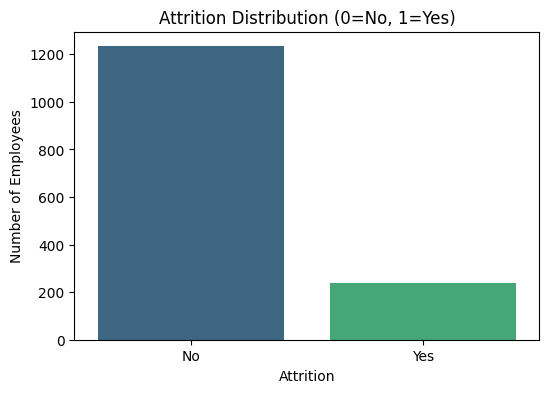

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

attrition_counts = df['Attrition'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=attrition_counts.index, y=attrition_counts.values, palette='viridis')
plt.title('Attrition Distribution (0=No, 1=Yes)')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()

### Salary vs Performance

C:\Users\moustafa\AppData\Local\Temp\ipykernel_20568\4133877299.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PerformanceRating', y='MonthlyIncome', data=avg_salary_by_performance, palette='magma')


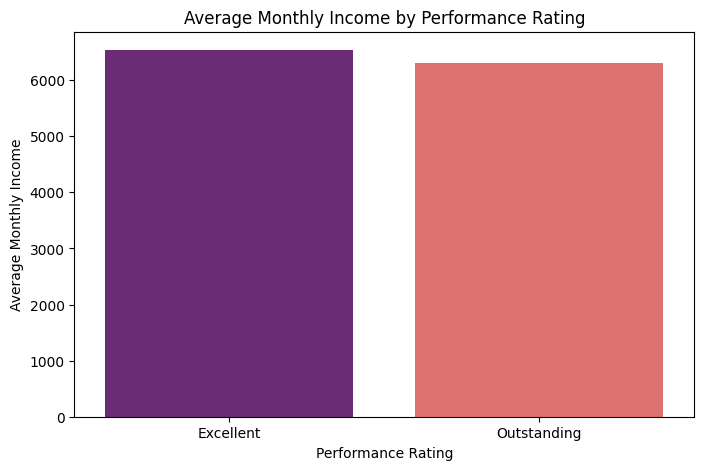

In [58]:
avg_salary_by_performance = df.groupby('PerformanceRating')['MonthlyIncome'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(x='PerformanceRating', y='MonthlyIncome', data=avg_salary_by_performance, palette='magma')
plt.title('Average Monthly Income by Performance Rating')
plt.xlabel('Performance Rating')
plt.ylabel('Average Monthly Income')
plt.show()

### Department Insights

C:\Users\moustafa\AppData\Local\Temp\ipykernel_20568\543270580.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Department', y='Attrition', data=attrition_by_department, palette='cividis')


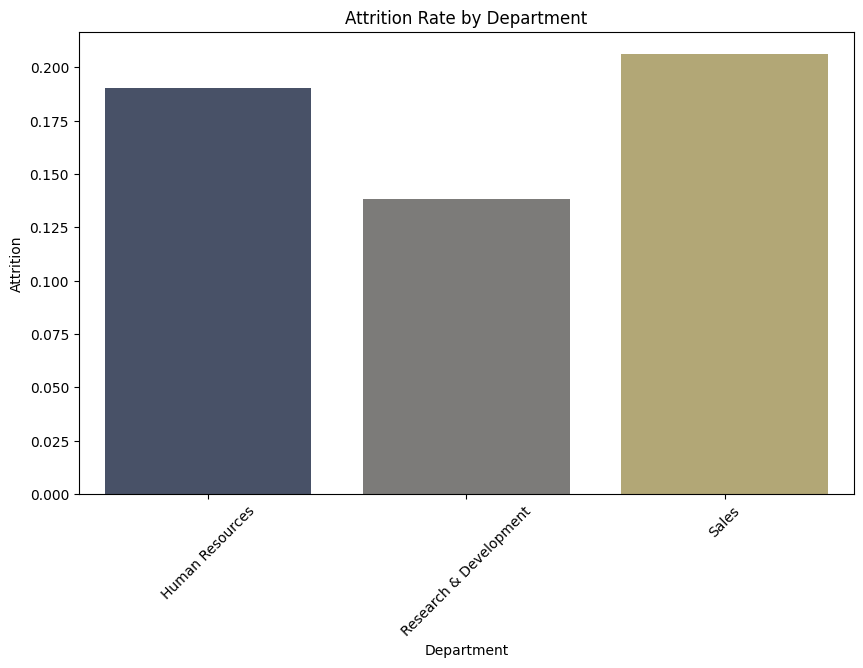

In [59]:
# convert to numeric
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# groupby
attrition_by_department = df.groupby('Department')['Attrition'].mean().reset_index()

# plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Department', y='Attrition', data=attrition_by_department, palette='cividis')
plt.title('Attrition Rate by Department')
plt.xticks(rotation=45)
plt.show()

C:\Users\moustafa\AppData\Local\Temp\ipykernel_20568\803647441.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Department', y='MonthlyIncome', data=avg_income_by_department, palette='rocket')


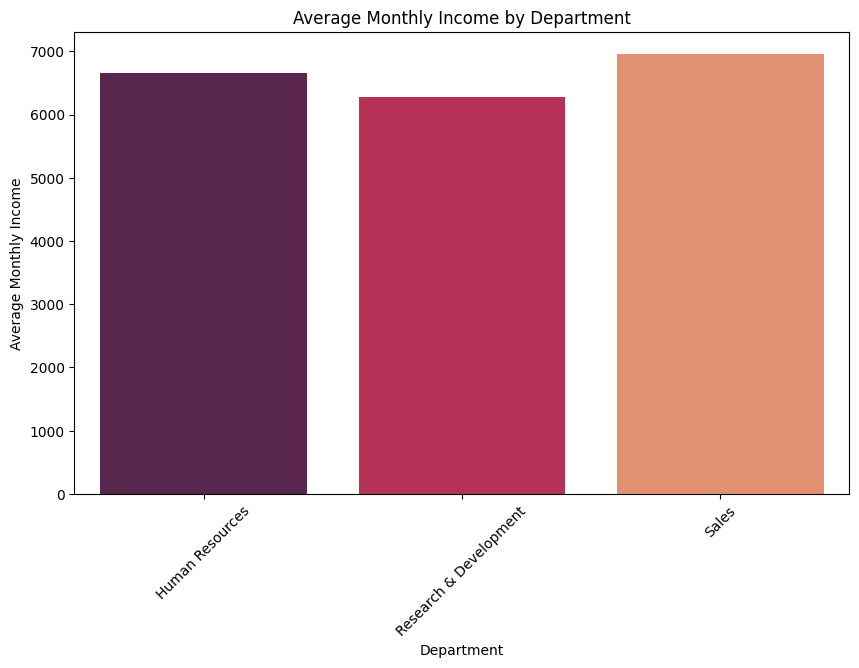

In [67]:
avg_income_by_department = df.groupby('Department')['MonthlyIncome'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Department', y='MonthlyIncome', data=avg_income_by_department, palette='rocket')
plt.title('Average Monthly Income by Department')
plt.xlabel('Department')
plt.ylabel('Average Monthly Income')
plt.xticks(rotation=45)
plt.show()

### Feature Engineering

In [62]:
df['JobSatisfaction'] = pd.factorize(df['JobSatisfaction'])[0]
df['WorkLifeBalance'] = pd.factorize(df['WorkLifeBalance'])[0]
df['EnvironmentSatisfaction'] = pd.factorize(df['EnvironmentSatisfaction'])[0]
df['JobInvolvement'] = pd.factorize(df['JobInvolvement'])[0]
df['PerformanceRating'] = pd.factorize(df['PerformanceRating'])[0]


df['Engagement'] = df['JobSatisfaction'] + df['WorkLifeBalance'] + df['EnvironmentSatisfaction'] + df['JobInvolvement']
df['Performance'] = df['PercentSalaryHike'] + df['TrainingTimesLastYear'] + df['PerformanceRating']

print(df[['Engagement', 'Performance']].head())

   Engagement  Performance
0           0           11
1           4           27
2           6           18
3           5           14
4           5           15


### Model Development

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score

df_clean = pd.read_csv("IBM-HR-Analytics-Employee-Attrition-and-Performance-Revised.csv")

df_encoded = df_clean.copy()
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop('Attrition', axis=1).select_dtypes(include=['number'])
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=0)
model.fit(X_train, y_train)

print('Accuracy(train):{:.3f}'.format(model.score(X_train, y_train)))
print('Accuracy(test):{:.3f}'.format(model.score(X_test, y_test)))
print('F1 Score:{:.3f}'.format(f1_score(y_test, model.predict(X_test), average='macro')))

Accuracy(train):0.868
Accuracy(test):0.851
F1 Score:0.536


### Clustering

In [64]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

X = df_encoded.select_dtypes(include=['number'])

# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=0)
df_encoded['Cluster'] = kmeans.fit_predict(X)

print('Cluster Distribution:')
print(df_encoded['Cluster'].value_counts())

Cluster Distribution:
Cluster
1    645
2    622
0    203
Name: count, dtype: int64


In [65]:
from sklearn.metrics import f1_score, classification_report, mean_squared_error, silhouette_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import numpy as np

# Classification F1-Score
y_pred = model.predict(X_test)
print('=== Classification ===')
print('F1 Score:{:.3f}'.format(f1_score(y_test, y_pred, average='macro')))
print(classification_report(y_test, y_pred, target_names=['Stay', 'Leave']))

# Regression on MonthlyIncome
y_reg = df_encoded['MonthlyIncome']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, random_state=0)
reg_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=0)
reg_model.fit(X_train_reg, y_train_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, reg_model.predict(X_test_reg)))
print('=== Regression ===')
print('RMSE:{:.3f}'.format(rmse))

# Clustering Silhouette Score
print('\n=== Clustering ===')
print('Silhouette Score:{:.3f}'.format(silhouette_score(X, df_encoded['Cluster'])))

=== Classification ===
F1 Score:0.536
              precision    recall  f1-score   support

        Stay       0.85      0.99      0.92       310
       Leave       0.71      0.09      0.15        58

    accuracy                           0.85       368
   macro avg       0.78      0.54      0.54       368
weighted avg       0.83      0.85      0.80       368

=== Regression ===
RMSE:83.421

=== Clustering ===
Silhouette Score:0.493


In [66]:
print('=== HR INSIGHTS ===')
print()
print('1. Attrition Rate by Cluster:')
print(df_encoded.groupby('Cluster')['Attrition'].mean().round(3))
print()
print('2. Average Monthly Income by Cluster:')
print(df_encoded.groupby('Cluster')['MonthlyIncome'].mean().round(0))
print()
print('3. High Risk Employees (Cluster 1 + Cluster 2 with Attrition=1):')
high_risk = df_encoded[(df_encoded['Cluster'].isin([1,2])) & (df_encoded['Attrition'] == 1)]
print('   Total:', len(high_risk))
print()
print('4. HR Strategies:')
print('   - Cluster 0: Retain top earners with leadership programs')
print('   - Cluster 1: Salary increase + career growth (highest risk)')
print('   - Cluster 2: Work-life balance + promotion opportunities (highest risk)')

=== HR INSIGHTS ===

1. Attrition Rate by Cluster:
Cluster
0    0.074
1    0.174
2    0.177
Name: Attrition, dtype: float64

2. Average Monthly Income by Cluster:
Cluster
0    16110.0
1     4761.0
2     5173.0
Name: MonthlyIncome, dtype: float64

3. High Risk Employees (Cluster 1 + Cluster 2 with Attrition=1):
   Total: 222

4. HR Strategies:
   - Cluster 0: Retain top earners with leadership programs
   - Cluster 1: Salary increase + career growth (highest risk)
   - Cluster 2: Work-life balance + promotion opportunities (highest risk)
